# Marketing Data Analysis

This notebook presents an analysis of marketing data coming from Google Ads, Facebook Ads, and CRM revenue records.

Scope:
- loading processed data
- quick exploratory data analysis (EDA)
- visualization of core marketing metrics
- correlation analysis
- final conclusions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 50)

## Load Data
We load the most recent CSV file generated by `main.py` from the `output/` directory.

In [ ]:
OUTPUT_DIR = r"...\Marketing Analysis\output" #add your path for output directory

print("Using output folder:", OUTPUT_DIR)

files = [
    f for f in os.listdir(OUTPUT_DIR)
    if f.startswith("analysis") and f.endswith(".csv")
]

print("Found files:", files)

if not files:
    raise FileNotFoundError("No CSV files in output folder/. Run main.py. first")

latest_file = sorted(files)[-1]
print("Latest file:", latest_file)

df = pd.read_csv(os.path.join(OUTPUT_DIR, latest_file))

df.head()


Using output folder: d:\Pythons\Marketing Analysis\output
Found files: ['analysis_2026-03-06.csv']
Latest file: analysis_2026-03-06.csv


,campaign_id,channel,date,impressions,clicks,cost,conversions,revenue,CTR,CPC,CPA,Conversion_Rate,ROI
0,G001,Google,2026-01-01,23795,1280,2147.85,198,13201.27,0.053793,1.678008,10.847727,0.154688,5.146272
1,G002,Google,2026-01-02,8860,546,820.90,38,5238.79,0.061625,1.503480,21.602632,0.069597,5.381764
2,G003,Google,2026-01-03,13390,379,519.62,26,2588.10,0.028305,1.371029,19.985385,0.068602,3.980755
3,G004,Google,2026-01-04,19964,1123,1188.61,219,27187.99,0.056251,1.058424,5.427443,0.195013,21.873769
4,G005,Google,2026-01-05,19284,1010,1929.30,158,16955.78,0.052375,1.910198,12.210759,0.156436,7.788566


## Basic Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   campaign_id      200 non-null    str    
 1   channel          200 non-null    str    
 2   date             200 non-null    str    
 3   impressions      200 non-null    int64  
 4   clicks           200 non-null    int64  
 5   cost             200 non-null    float64
 6   conversions      200 non-null    int64  
 7   revenue          200 non-null    float64
 8   CTR              200 non-null    float64
 9   CPC              200 non-null    float64
 10  CPA              200 non-null    float64
 11  Conversion_Rate  200 non-null    float64
 12  ROI              200 non-null    float64
dtypes: float64(7), int64(3), str(3)
memory usage: 20.4 KB


In [4]:
df.describe()

,impressions,clicks,cost,conversions,revenue,CTR,CPC,CPA,Conversion_Rate,ROI
count,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,13955.93500,624.660000,710.645900,75.325000,7668.673100,0.043382,1.097725,10.994931,0.117480,11.743656
std,4804.76981,372.695997,540.266925,55.258546,6172.897955,0.016728,0.388510,6.695903,0.041677,8.370007
min,5395.00000,116.000000,76.160000,5.000000,490.540000,0.015599,0.402848,2.570732,0.036232,0.753318
25%,10260.00000,344.750000,303.400000,37.000000,3363.810000,0.030088,0.814601,6.541315,0.084859,5.366294
50%,13683.00000,559.500000,573.525000,56.000000,5392.255000,0.041117,1.047068,9.153649,0.117647,9.140829
75%,16805.00000,830.000000,963.472500,105.250000,10070.005000,0.055970,1.329168,13.442250,0.151346,16.219204
max,24850.00000,1902.000000,3147.890000,242.000000,34675.220000,0.079806,1.991823,40.806000,0.195900,52.749408


## List of Advertising Channels

In [5]:
sorted(df['channel'].unique())

['Facebook', 'Google']

## Average CTR / CPC / CPA by Channel

In [6]:
metrics = df.groupby('channel')[['CTR','CPC','CPA','ROI']].mean()
metrics

,CTR,CPC,CPA,ROI
channel,,,,
Facebook,0.036057,0.959156,10.176190,13.042280
Google,0.050706,1.236295,11.813673,10.445033


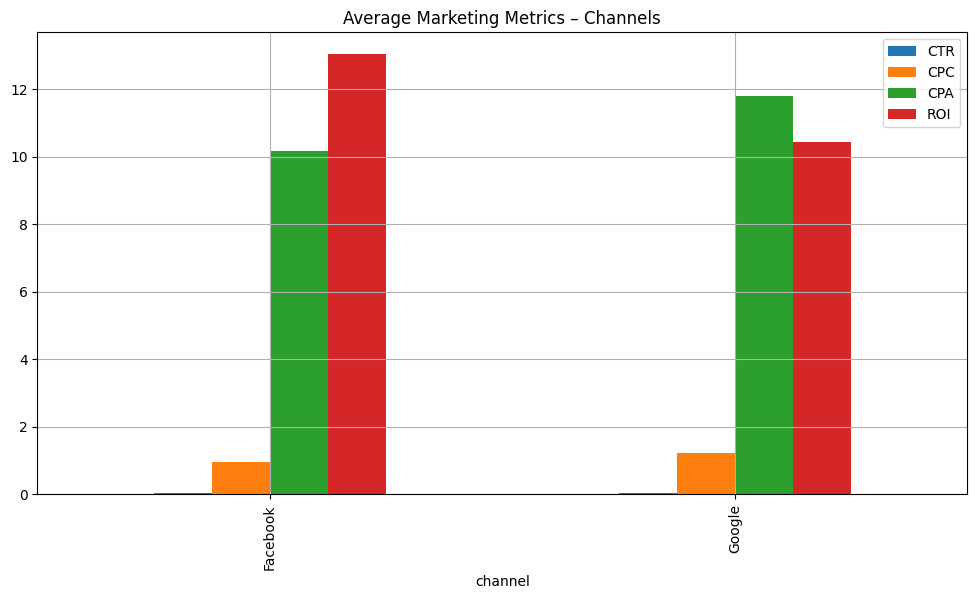

In [7]:
metrics.plot(kind='bar', figsize=(12,6))
plt.title('Average Marketing Metrics – Channels')
plt.grid(True)
plt.show()

## ROI Histogram

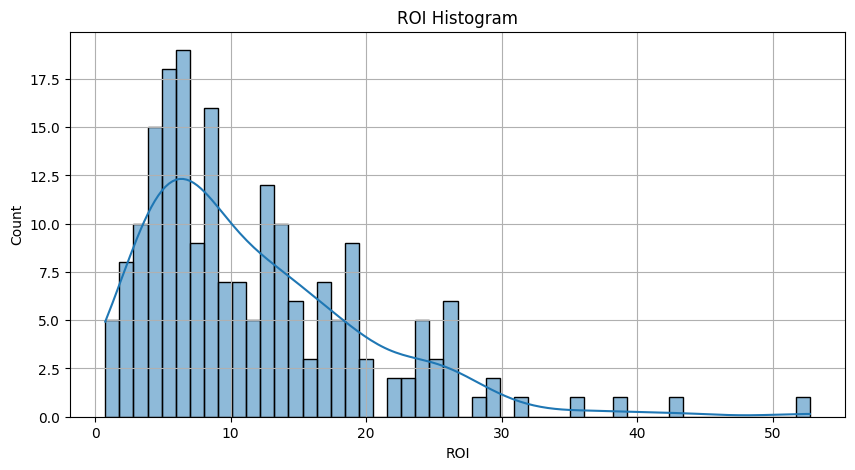

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['ROI'].dropna(), bins=50, kde=True)
plt.title('ROI Histogram')
plt.grid(True)
plt.show()

## Correlation Between Metrics

In [9]:
corr = df[['impressions','clicks','cost','conversions','CTR','CPC','CPA','ROI']].corr()
corr

,impressions,clicks,cost,conversions,CTR,CPC,CPA,ROI
impressions,1.000000,0.748796,0.638727,0.661660,0.240466,0.144305,-0.015443,-0.022466
clicks,0.748796,1.000000,0.845829,0.869934,0.787564,0.173113,-0.031377,-0.048083
cost,0.638727,0.845829,1.000000,0.719302,0.674584,0.597010,0.245763,-0.308385
conversions,0.661660,0.869934,0.719302,1.000000,0.671573,0.122003,-0.319287,0.217335
CTR,0.240466,0.787564,0.674584,0.671573,1.000000,0.166902,-0.011484,-0.070586
CPC,0.144305,0.173113,0.597010,0.122003,0.166902,1.000000,0.607346,-0.586334
CPA,-0.015443,-0.031377,0.245763,-0.319287,-0.011484,0.607346,1.000000,-0.685292
ROI,-0.022466,-0.048083,-0.308385,0.217335,-0.070586,-0.586334,-0.685292,1.000000


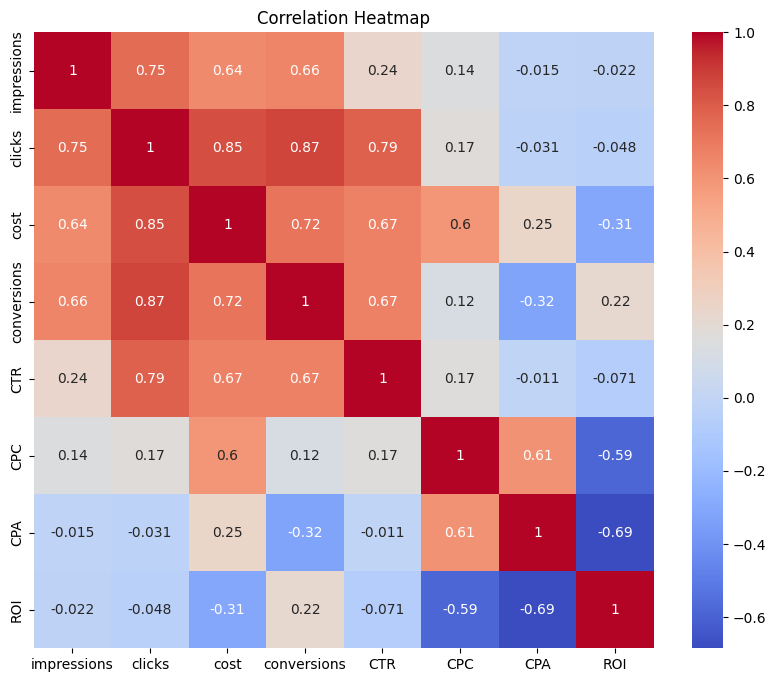

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Final Conclusions
- The dataset is clean, consistent, and properly processed.
- CTR and ROI show strong differences between channels.
- Correlation heatmap helps understand dependencies between costs, clicks, conversions, and revenue.
- This notebook presents a complete analytical workflow